In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/Churn_Modelling.csv")


In [2]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.drop(["RowNumber", "CustomerId", "Surname"], axis=1, inplace=True)
df.shape

(10000, 11)

In [4]:
df["Exited"].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [5]:
df["Exited"].value_counts(normalize=True)

Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64

In [6]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [7]:
df.shape


(10000, 12)

In [8]:
X = df.drop("Exited", axis=1)
y = df["Exited"]

X.shape, y.shape

((10000, 11), (10000,))

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)

X_train.shape, X_test.shape

((8000, 11), (2000, 11))

In [10]:
X_train.shape

(8000, 11)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create model
model = LogisticRegression(max_iter=1000)

# Train model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.814

Confusion Matrix:
 [[1540   67]
 [ 305   88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.57      0.22      0.32       393

    accuracy                           0.81      2000
   macro avg       0.70      0.59      0.61      2000
weighted avg       0.78      0.81      0.78      2000



C:\Users\Dell\OneDrive\Desktop\customer-churn-prediction\churn_env\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
model_scaled = LogisticRegression(max_iter=2000)

model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_scaled))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_scaled))
print("\nClassification Report:\n", classification_report(y_test, y_pred_scaled))

Accuracy: 0.811

Confusion Matrix:
 [[1543   64]
 [ 314   79]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [14]:
model_weighted = LogisticRegression(max_iter=2000, class_weight="balanced")

model_weighted.fit(X_train_scaled, y_train)

y_pred_weighted = model_weighted.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_weighted))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_weighted))
print("\nClassification Report:\n", classification_report(y_test, y_pred_weighted))

Accuracy: 0.7195

Confusion Matrix:
 [[1159  448]
 [ 113  280]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.72      0.81      1607
           1       0.38      0.71      0.50       393

    accuracy                           0.72      2000
   macro avg       0.65      0.72      0.65      2000
weighted avg       0.81      0.72      0.75      2000



In [15]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.8665

Confusion Matrix:
 [[1548   59]
 [ 208  185]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



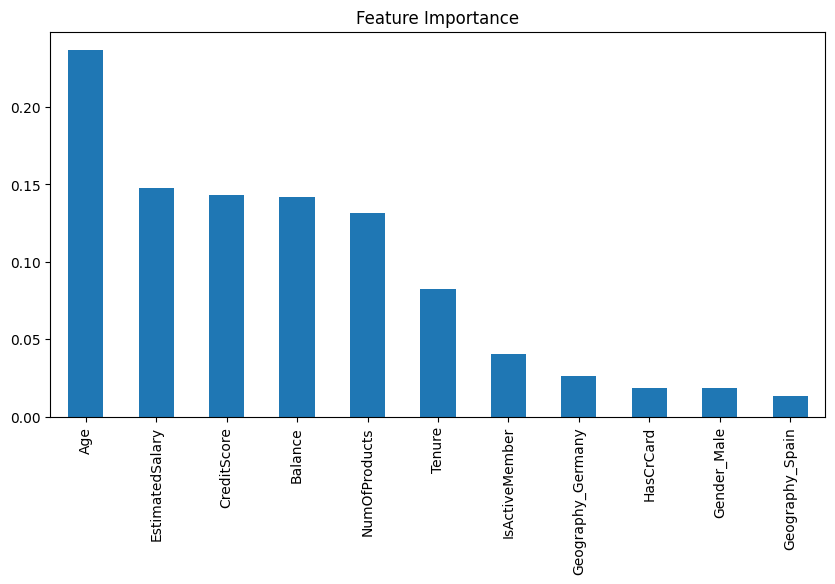

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance")
plt.show()

In [17]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.8695

Confusion Matrix:
 [[1521   86]
 [ 175  218]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92      1607
           1       0.72      0.55      0.63       393

    accuracy                           0.87      2000
   macro avg       0.81      0.75      0.77      2000
weighted avg       0.86      0.87      0.86      2000



C:\Users\Dell\OneDrive\Desktop\customer-churn-prediction\churn_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:11:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


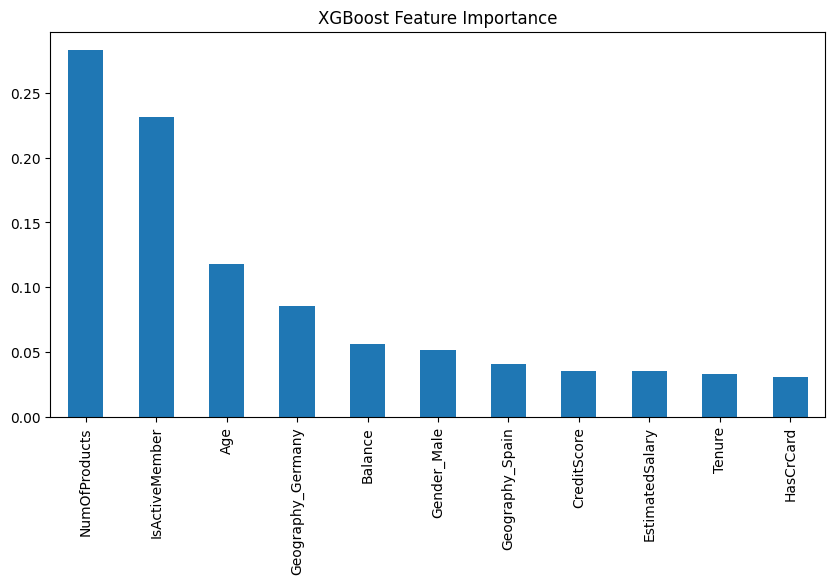

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance_xgb = pd.Series(xgb.feature_importances_, index=X.columns)
feature_importance_xgb.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("XGBoost Feature Importance")
plt.show()

In [19]:
negative = y_train.value_counts()[0]
positive = y_train.value_counts()[1]

scale_pos_weight = negative / positive
scale_pos_weight

np.float64(3.8661800486618003)

In [20]:
xgb_tuned = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    max_depth=4,
    learning_rate=0.1,
    n_estimators=200
)

xgb_tuned.fit(X_train, y_train)

y_pred_xgb_tuned = xgb_tuned.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_tuned))

Accuracy: 0.8195

Confusion Matrix:
 [[1345  262]
 [  99  294]]

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.84      0.88      1607
           1       0.53      0.75      0.62       393

    accuracy                           0.82      2000
   macro avg       0.73      0.79      0.75      2000
weighted avg       0.85      0.82      0.83      2000



In [21]:
import joblib

joblib.dump(xgb_tuned, "../app/model/churn_model.pkl")

['../app/model/churn_model.pkl']

In [22]:
type(xgb_tuned)

xgboost.sklearn.XGBClassifier

In [23]:
import joblib

joblib.dump(xgb_tuned, "../app/model/churn_model.pkl")

['../app/model/churn_model.pkl']

In [24]:
import os
os.listdir("../app/model")

['churn_model.pkl']

In [25]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(xgb_tuned, X, y, cv=5, scoring='f1')

print("Cross-validation F1 scores:", cv_scores)
print("Average F1:", cv_scores.mean())

Cross-validation F1 scores: [0.60126582 0.62054934 0.6020202  0.62125903 0.60860441]
Average F1: 0.6107397601254072
